# Data Setup & Preprocessing

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer


df = pd.read_csv('Titanic-Dataset.csv')


df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)


X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']]
y = df['Survived']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)


num_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']
cat_features = ['Sex', 'Embarked']

preprocessor = ColumnTransformer(transformers=[
    ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), num_features),
    ('cat', make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(handle_unknown='ignore', sparse_output=False)), cat_features)
])


X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)


cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehotencoder']
cat_feature_names = list(cat_encoder.get_feature_names_out(cat_features))
all_feature_names = num_features + cat_feature_names

print("Data processing complete. Feature count:", len(all_feature_names))

# Train All Models & Performance Comparison Table

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

results = []

# Train & Evaluate each model
for name, model in models.items():
    model.fit(X_train_prep, y_train)
    preds = model.predict(X_test_prep)
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds)
    })


comparison_df = pd.DataFrame(results)
display(comparison_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.804469,0.783333,0.681159,0.728682
1,Decision Tree,0.793296,0.750000,0.695652,0.721805
2,Random Forest,0.810056,0.786885,0.695652,0.738462
3,XGBoost,0.793296,0.735294,0.724638,0.729927


# Feature Importances & Ensemble Differences Summary

C:\Users\DELL\AppData\Local\Temp\ipykernel_16008\2020961428.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Random Forest', y='Feature', data=importance_df, ax=axes[0], palette='Blues_r')
C:\Users\DELL\AppData\Local\Temp\ipykernel_16008\2020961428.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='XGBoost', y='Feature', data=importance_df.sort_values(by='XGBoost', ascending=False), ax=axes[1], palette='Oranges_r')


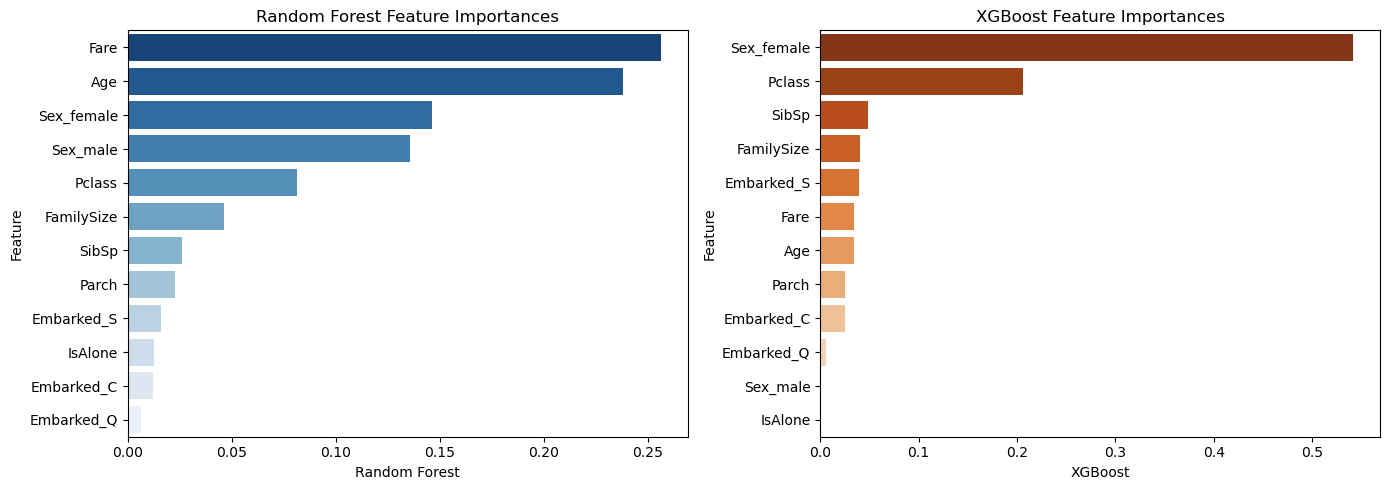


RANDOM FOREST vs. XGBOOST: ENSEMBLE METHODOLOGY DIFFERENCES
1. Bagging vs. Boosting:
   Random Forest uses Bagging (Bootstrap Aggregating) by training multiple decision 
   trees in parallel on independent random sub-samples of data and averaging their 
   predictions to reduce variance. XGBoost uses Gradient Boosting by training 
   decision trees sequentially, where each new tree specifically focuses on correcting 
   the residual errors made by the previous trees.

2. Tree Depth & Complexity:
   Random Forest typically builds fully grown, deep decision trees, whereas XGBoost 
   builds shallow trees (weak learners) and sequentially combines them.

3. Optimization & Regularization:
   XGBoost incorporates L1 (Lasso) and L2 (Ridge) regularization directly into its 
   loss function to prevent overfitting, which generally yields better generalization 
   on structured tabular data than standard Random Forest.



In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

rf_model = models['Random Forest']
xgb_model = models['XGBoost']


importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Random Forest': rf_model.feature_importances_,
    'XGBoost': xgb_model.feature_importances_
}).sort_values(by='Random Forest', ascending=False)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x='Random Forest', y='Feature', data=importance_df, ax=axes[0], palette='Blues_r')
axes[0].set_title('Random Forest Feature Importances')

sns.barplot(x='XGBoost', y='Feature', data=importance_df.sort_values(by='XGBoost', ascending=False), ax=axes[1], palette='Oranges_r')
axes[1].set_title('XGBoost Feature Importances')

plt.tight_layout()
plt.show()

# Written Explanation of Ensemble Differences 
ensemble_explanation = """
================================================================================
RANDOM FOREST vs. XGBOOST: ENSEMBLE METHODOLOGY DIFFERENCES
================================================================================
1. Bagging vs. Boosting:
   Random Forest uses Bagging (Bootstrap Aggregating) by training multiple decision 
   trees in parallel on independent random sub-samples of data and averaging their 
   predictions to reduce variance. XGBoost uses Gradient Boosting by training 
   decision trees sequentially, where each new tree specifically focuses on correcting 
   the residual errors made by the previous trees.

2. Tree Depth & Complexity:
   Random Forest typically builds fully grown, deep decision trees, whereas XGBoost 
   builds shallow trees (weak learners) and sequentially combines them.

3. Optimization & Regularization:
   XGBoost incorporates L1 (Lasso) and L2 (Ridge) regularization directly into its 
   loss function to prevent overfitting, which generally yields better generalization 
   on structured tabular data than standard Random Forest.
================================================================================
"""

print(ensemble_explanation)